# Учись Машина Учись / Learn Machine Learn

<img src="data/lml.png" width=200>

Онлайн-лекции Ильи С. Елисеева: применение методов машинного обучения в анализе данных.

- Канал в Telegram: https://t.me/learn_machine_learn
- YouTube: https://www.youtube.com/channel/UCCwDwKatNitBCVAJajremMQ
- VK: https://vk.com/learn_machine_learn
- GitHub: https://github.com/easyise/learn_machine_learn

---



# Асинхронное программирование в Python

Асинхронное программированое - это основа для решения следующих задач:
- выстраивание очередей задач для внешних сервисов (например, для API);
- распараллеливание задач, которые не требуют блокировки (например, запросы к базе данных);
- обработка большого количества соединений (например, веб-серверы, чат-сервисы, телеграм-боты).

В Python асинхронное программирование реализовано через ключевые слова `async` и `await`. Основные библиотеки для работы с асинхронным кодом:
- `asyncio` - стандартная библиотека для асинхронного программирования в Python;
- `aiohttp` - библиотека для работы с HTTP-запросами в асинхронном режиме;
- `aiomysql` - библиотека для работы с MySQL в асинхронном режиме;
- `aioredis` - библиотека для работы с Redis в асинхронном режиме.

Сегодня я расскажу вам об асинхронном программировании вообще и покажу, как это работает на примере модели-маршрутизатора: она будет решать на сколько сложная задача и отправлять ее на выполнение либо себе самой, либо внешнему провайдеру через OpenAI API.

## 1. Асинхронные функции и корутины

In [20]:
# обычный последовательный запуск функций
import time

def worker(name):
    print(f"{name}: начало")
    time.sleep(1)
    print(f"{name}: конец")
    print()


worker("A")
worker("B")
worker("C")

A: начало
A: конец

B: начало
B: конец

C: начало
C: конец



### 1.1 Корутины

In [22]:
# корутина - функция для асинхронного выполнения
async def worker():
    print("Старт")

    time.sleep(1)

    print("Конец")


await worker()

Старт
Конец


In [23]:
worker()

<coroutine object worker at 0x105c86d40>

In [26]:
# возвращаемые значения
async def worker_sum(a, b):
    print(f"Сумма {a} + {b} = {a + b}")
    return a + b

x = await worker_sum(2, 2)
x

Сумма 2 + 2 = 4


4

In [27]:
# как работает yield в корутинах
async def worker_yield():
    yield 2
    time.sleep(1)
    yield 12
    time.sleep(1)
    yield 85
    time.sleep(1)
    yield 0
    time.sleep(1)
    yield 6

async for value in worker_yield():
    print(value)


2
12
85
0
6


### 1.2 Event loop

Event loop - это цикл событий, который управляет выполнением асинхронных задач. Он позволяет запускать несколько задач одновременно, не блокируя выполнение программы.

В Jupyter Notebook event loop уже запущен, поэтому мы можем использовать `await` для вызова асинхронных функций. В обычном Python скрипте нужно использовать `asyncio.run()` для запуска event loop (см. пример с ```04-async-event_loop.py```)

In [19]:
# две корутины:

# первая
async def worker(name):
    print(f"{name}: старт")

    time.sleep(1)

    print(f"{name}: конец")
    print()

# вторая
async def main():
    await worker("A")
    await worker("B")
    await worker("C")


await main()

A: старт
A: конец

B: старт
B: конец

C: старт
C: конец



In [25]:
# универсальная функция для запуска корутин в разных средах (Jupyter Notebook, консолька, web, etc...)
import asyncio


def run_worker():
    try:
        loop = asyncio.get_running_loop()
        loop.create_task(worker())  # notebook/active loop
    except RuntimeError:
        asyncio.run(worker())   # normal .py script
    
    
run_worker()

Старт
Конец


### 1.3 Параллельное выполнение корутин

Используется `asyncio.gather()` для параллельного выполнения нескольких корутин. Это позволяет запускать несколько задач одновременно и ожидать их завершения.

In [30]:
async def worker(name):
    print(f"{name}: старт")

    await asyncio.sleep(2)

    print(f"{name}: конец")



await asyncio.gather(
    worker("A"),
    worker("B"),
    worker("C")
)



A: старт
B: старт
C: старт
A: конец
B: конец
C: конец


[None, None, None]

In [31]:
async def worker(name):
    for i in range(5):
        print(f"{name}: шаг {i}")

        await asyncio.sleep(0.5) # <-- как бы говорит: "дальше там без меня на полсекунды"


await asyncio.gather(
        worker("A"),
        worker("B")
    );

A: шаг 0
B: шаг 0
A: шаг 1
B: шаг 1
A: шаг 2
B: шаг 2
A: шаг 3
B: шаг 3
A: шаг 4
B: шаг 4


In [ ]:
async def bad_worker(name):
    for i in range(5):
        print(f"{name}: шаг {i}")

        time.sleep(0.5) # <-- блокирует event loop: "всем ждать, пока я посплю полсекунды!"


await asyncio.gather(
        bad_worker("A"),
        bad_worker("B")
    );

A: шаг 0
A: шаг 1
A: шаг 2
A: шаг 3
A: шаг 4
B: шаг 0
B: шаг 1
B: шаг 2
B: шаг 3
B: шаг 4


### 1.4 Сбор возвращаемых значений



In [32]:
async def worker_sum(a, b):
    print(f"Сумма {a} + {b} = {a + b}")
    return a + b

x = await asyncio.gather(
    worker_sum(2, 2),
    worker_sum(3, 3),
    worker_sum(4, 4)
)

print(x)  # [4, 6, 8]

Сумма 2 + 2 = 4
Сумма 3 + 3 = 6
Сумма 4 + 4 = 8
[4, 6, 8]


### 1.5 Асинхронно != многопоточно

In [ ]:
# не блокирует event loop
async def complex_task():
    await asyncio.sleep(5)
    return "Готово"

# блокирует event loop
async def bad_complex_task():
    time.sleep(5)
    return "Готово"


async def print_progress(task):
    while not task.done():
        print(".", end="", flush=True)
        await asyncio.sleep(0.5)


async def main():
    print("Начало работы...")
    task = asyncio.create_task(complex_task())
    # task = asyncio.create_task(bad_complex_task())
    progress = asyncio.create_task(print_progress(task))

    result = await task
    await progress

    print()
    print(result)


await main()

In [40]:
async def cpu_heavy(name):
    print(name, "старт")

    s = 0

    for i in range(100_000_000):
        s += i

    print(name, "конец")


async def main():
    await asyncio.gather(
        cpu_heavy("A"),
        cpu_heavy("B")
    )


start = time.perf_counter()

await main()

elapsed = time.perf_counter() - start

print()
print(f"Время: {elapsed:.2f} сек")

A старт
A конец
B старт
B конец

Время: 5.13 сек


In [42]:
# добавим в цикл await
async def cpu_heavy(name):
    for i in range(10):

        print(name, i)

        for _ in range(10_000_000):
            pass

        await asyncio.sleep(0)


await asyncio.gather(
        cpu_heavy("A"),
        cpu_heavy("B")
    );

A 0
B 0
A 1
B 1
A 2
B 2
A 3
B 3
A 4
B 4
A 5
B 5
A 6
B 6
A 7
B 7
A 8
B 8
A 9
B 9


**ВЫВОД**

Для вычислительных задач, которые требуют много ресурсов процессора, асинхронное программирование не даст прироста производительности. В таких случаях лучше использовать многопроцессность (`multiprocessing`, `ProcessPoolExecutor`).

Для задач, которые требуют ожидания (например, запросы к внешним сервисам), асинхронное программирование позволяет эффективно использовать ресурсы и ускорять выполнение программы.

## 2. Практическое применение

### 2.1 Очереди

In [2]:
import asyncio
import random


async def producer(queue: asyncio.Queue, count: int):
    for task_id in range(1, count + 1):
        task = {
            "id": task_id,
            "duration": random.uniform(0.5, 2.0),
        }

        await queue.put(task)
        print(f"Добавлена задача {task_id}")

    print("Все задачи добавлены")


async def worker(name: str, queue: asyncio.Queue):
    while True:
        task = await queue.get()

        try:
            print(
                f"{name} начал задачу {task['id']} "
                f"({task['duration']:.1f} сек)"
            )

            await asyncio.sleep(task["duration"])

            print(f"{name} завершил задачу {task['id']}")

        finally:
            queue.task_done()


async def main():
    queue = asyncio.Queue(maxsize=3) # создаем очередь с ограничением на 3 задачи одновременно

    workers = [
        asyncio.create_task(worker(f"Worker-{i}", queue))
        for i in range(1, 4)
    ]

    await producer(queue, count=10)

    await queue.join()

    for task in workers:
        task.cancel()

    await asyncio.gather(
        *workers,
        return_exceptions=True,
    )

    print("Очередь обработана")


await main()

Добавлена задача 1
Добавлена задача 2
Добавлена задача 3
Worker-1 начал задачу 1 (1.4 сек)
Worker-2 начал задачу 2 (1.0 сек)
Worker-3 начал задачу 3 (1.2 сек)
Добавлена задача 4
Добавлена задача 5
Добавлена задача 6
Worker-2 завершил задачу 2
Worker-2 начал задачу 4 (1.2 сек)
Добавлена задача 7
Worker-3 завершил задачу 3
Worker-3 начал задачу 5 (0.6 сек)
Добавлена задача 8
Worker-1 завершил задачу 1
Worker-1 начал задачу 6 (0.8 сек)
Добавлена задача 9
Worker-3 завершил задачу 5
Worker-3 начал задачу 7 (1.8 сек)
Добавлена задача 10
Все задачи добавлены
Worker-1 завершил задачу 6
Worker-1 начал задачу 8 (1.4 сек)
Worker-2 завершил задачу 4
Worker-2 начал задачу 9 (1.1 сек)
Worker-2 завершил задачу 9
Worker-2 начал задачу 10 (0.5 сек)
Worker-3 завершил задачу 7
Worker-1 завершил задачу 8
Worker-2 завершил задачу 10
Очередь обработана


### 2.2 Одновременная загрузка из Интернета

Пример: загрузка курсов валют за разные годы с сайта `frankfurter.app`. Мы будем использовать асинхронные запросы для ускорения процесса загрузки данных.

Для этого нельзя использовать `requests`, так как она блокирует выполнение программы. Вместо этого мы будем использовать `aiohttp`, которая позволяет делать асинхронные HTTP-запросы.

In [3]:
%pip install aiohttp

Note: you may need to restart the kernel to use updated packages.


In [4]:
import asyncio
import aiohttp
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
YEARS = [2022, 2023, 2024]

BASE = "EUR"
QUOTE = "USD"

API_URL = "https://api.frankfurter.dev/v2/rates"

In [6]:
async def load_year(
    session: aiohttp.ClientSession,
    year: int,
) -> pd.DataFrame:
    
    params = {
        "from": f"{year}-01-01",
        "to": f"{year}-12-31",
        "base": BASE,
        "quotes": QUOTE,
    }

    print(f"{year}: загрузка началась")

    async with session.get(
        API_URL,
        params=params,
    ) as response:
        response.raise_for_status()
        data = await response.json()

    frame = pd.DataFrame(data)

    frame["date"] = pd.to_datetime(frame["date"])
    frame["day_of_year"] = frame["date"].dt.dayofyear
    frame["year"] = year

    print(f"{year}: загружено {len(frame)} значений")

    return frame[
        ["date", "day_of_year", "year", "rate"]
    ]

In [7]:
async def load_all_years(
    years: list[int],
) -> list[pd.DataFrame]:
    timeout = aiohttp.ClientTimeout(total=30)

    async with aiohttp.ClientSession(
        timeout=timeout
    ) as session:
        tasks = [
            load_year(session, year)
            for year in years
        ]

        return await asyncio.gather(*tasks)

In [10]:
timeout = aiohttp.ClientTimeout(total=30)

async with aiohttp.ClientSession(
    timeout=timeout,
    headers={"Accept-Encoding": "gzip, deflate, identity"},
) as session:
    frames = await asyncio.gather(
        *(load_year(session, year) for year in YEARS)
    )

rates = pd.concat(
    frames,
    ignore_index=True,
)

rates

2022: загрузка началась
2023: загрузка началась
2024: загрузка началась
2023: загружено 365 значений
2024: загружено 366 значений
2022: загружено 365 значений


,date,day_of_year,year,rate
0,2022-01-01,1,2022,1.1311
1,2022-01-02,2,2022,1.1310
2,2022-01-03,3,2022,1.1323
3,2022-01-04,4,2022,1.1294
4,2022-01-05,5,2022,1.1296
...,...,...,...,...
1091,2024-12-27,362,2024,1.0425
1092,2024-12-28,363,2024,1.0428
1093,2024-12-29,364,2024,1.0429
1094,2024-12-30,365,2024,1.0435


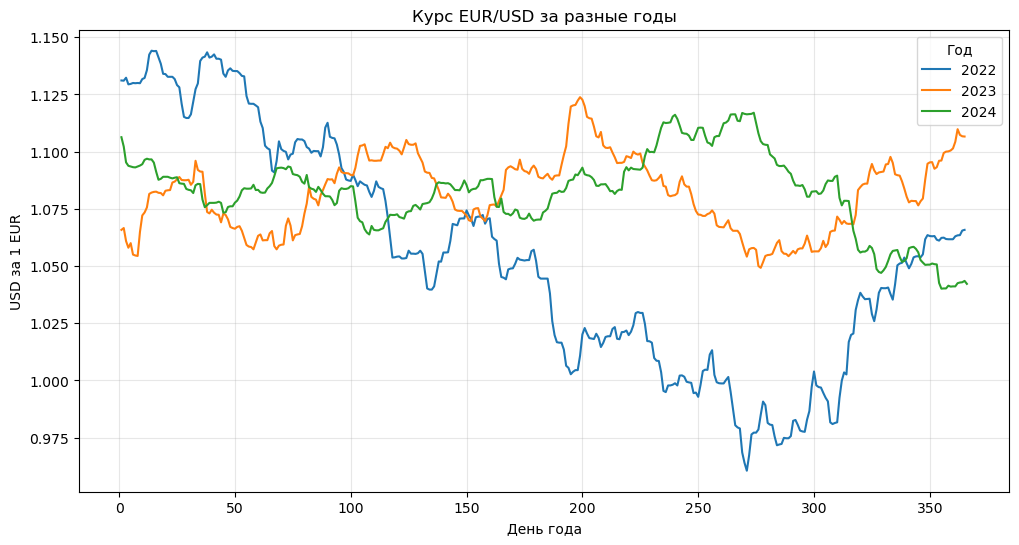

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))

for year, frame in rates.groupby("year"):
    ax.plot(
        frame["day_of_year"],
        frame["rate"],
        label=str(year),
    )

ax.set_title(
    f"Курс {BASE}/{QUOTE} за разные годы"
)
ax.set_xlabel("День года")
ax.set_ylabel(
    f"{QUOTE} за 1 {BASE}"
)
ax.legend(title="Год")
ax.grid(True, alpha=0.3)

plt.show()

### 2.3 Асинхронный запуск нейросетей



In [12]:
%pip install -q --upgrade openai

Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
import asyncio
import time

from openai import AsyncOpenAI

In [46]:
from __config__ import *

# Локальный llama.cpp на домашнем сервере BrainBox.
LOCAL_BASE_URL = "http://brainbox:8080/v1"
LOCAL_API_KEY = "an_api_key"

# Имя модели здесь может быть произвольным:
# llama.cpp обычно не использует его для выбора модели,
# если сервер запущен только с одной моделью.
LOCAL_MODEL = "gemma-4-12b"


# Внешний OpenAI-совместимый провайдер.
# Адрес, ключ и модель удобно задавать через переменные окружения.
CLOUD_BASE_URL = os.getenv(
    "CLOUD_BASE_URL",
    "https://api.openai.com/v1",
)

CLOUD_API_KEY = OPENAI_API_KEY

CLOUD_MODEL = os.getenv(
    "CLOUD_MODEL",
    "gpt-5.5",
)

In [8]:
local_client = AsyncOpenAI(
    base_url=LOCAL_BASE_URL,
    api_key=LOCAL_API_KEY,
    timeout=60.0,
    max_retries=1,
)

cloud_client = AsyncOpenAI(
    base_url=CLOUD_BASE_URL,
    api_key=CLOUD_API_KEY,
    timeout=120.0,
    max_retries=1,
)

In [62]:
async def test_local_model():
    response = await local_client.chat.completions.create(
        model=LOCAL_MODEL,
        messages=[
            {
                "role": "system",
                "content": (
                    "Отвечай кратко, одним предложением."
                ),
            },
            {
                "role": "user",
                "content": (
                    "Объясни асинхронное программирование "
                    "на примере официанта."
                ),
            },
        ],
        temperature=1.0,
    )

    return response.choices[0].message.content


await test_local_model()

'Асинхронное программирование — это когда официант принимает заказ и идет обслуживать другие столики, не дожидаясь, пока повар приготовит блюдо.'

In [71]:
async def stream_llm(
    client: AsyncOpenAI,
    model: str,
    prompt: str,
) -> str:
    stream = await client.chat.completions.create(
        model=model,
        messages=[
            {
                "role": "system",
                "content": (
                    "Отвечай кратко, одним предложением."
                ),
            },
            {
                "role": "user",
                "content": prompt,
            }
        ],
        temperature=1.0,
        stream=True,
    )

    full_answer = ""
    thinking = ''

    async for chunk in stream:
        reasoning_token = chunk.choices[0].delta.reasoning_content if hasattr(chunk.choices[0].delta, 'reasoning_content') else None
        token = chunk.choices[0].delta.content

        if thinking == '' and reasoning_token:
            print('Thinking: ')
        if reasoning_token:
            thinking += reasoning_token
            print(reasoning_token, end="", flush=True)

        if full_answer == '' and token:
            print('\nAnswer: ')
        if token:
            print(token, end="", flush=True)
            full_answer += token

    print()

    return full_answer

In [72]:
answer = await stream_llm(
    client=local_client,
    model=LOCAL_MODEL,
    prompt=(
        "Объясни асинхронное программирование "
        "на примере официанта."
    ),
)

Thinking: 
*   Topic: Asynchronous programming.
    *   Analogy: A waiter.
    *   Constraint: Brief, one sentence.
    *   Language: Russian.

    *   Synchronous: Waiter takes an order, goes to kitchen, waits for the dish to be ready (blocking), then brings it to the table.
    *   Asynchronous: Waiter takes an order, gives it to the kitchen, and while the food is being prepared, attends to other tables (non-blocking).

    *   *Draft 1:* Асинхронное программирование — это когда официант принимает заказ, передает его на кухню и идет обслуживать других гостей, не дожидаясь готовности блюда. (Good, clear).
    *   *Draft 2:* Это когда официант не стоит у плиты, ожидая еду, а идет выполнять другие задачи, пока повар готовит заказ. (Also good).
    *   *Draft 3 (More concise):* Асинхронное программирование подобно официанту, который принимает заказ и идет обслуживать других гостей, пока повар готовит блюдо, вместо того чтобы стоять и ждать у кухни.

    "Асинхронное программирование — эт

In [59]:
async def debug_stream(prompt: str):
    stream = await local_client.chat.completions.create(
        model=LOCAL_MODEL,
        messages=[
            {
                "role": "user",
                "content": prompt,
            }
        ],
        max_tokens=500,
        stream=True,
    )

    async for chunk in stream:
        print(repr(chunk.choices[0].delta), flush=True)

await debug_stream("Напиши пять коротких предложений.")

ChoiceDelta(content=None, function_call=None, refusal=None, role='assistant', tool_calls=None)
ChoiceDelta(content=None, function_call=None, refusal=None, role=None, tool_calls=None, reasoning_content='"')
ChoiceDelta(content=None, function_call=None, refusal=None, role=None, tool_calls=None, reasoning_content='На')
ChoiceDelta(content=None, function_call=None, refusal=None, role=None, tool_calls=None, reasoning_content='пи')
ChoiceDelta(content=None, function_call=None, refusal=None, role=None, tool_calls=None, reasoning_content='ши')
ChoiceDelta(content=None, function_call=None, refusal=None, role=None, tool_calls=None, reasoning_content=' пять')
ChoiceDelta(content=None, function_call=None, refusal=None, role=None, tool_calls=None, reasoning_content=' корот')
ChoiceDelta(content=None, function_call=None, refusal=None, role=None, tool_calls=None, reasoning_content='ких')
ChoiceDelta(content=None, function_call=None, refusal=None, role=None, tool_calls=None, reasoning_content=' пред')

In [19]:
ROUTER_SYSTEM_PROMPT = """
Ты — маршрутизатор запросов между двумя языковыми моделями.

LOCAL:
- небольшая локальная модель;
- работает бесплатно;
- данные не покидают локальную сеть;
- подходит для коротких и простых задач.

CLOUD:
- большая внешняя модель;
- лучше справляется со сложным анализом;
- её вызов дороже;
- запрос покидает локальную сеть.

Выбери LOCAL, если запрос:
- требует короткого ответа;
- является переводом или перефразированием;
- содержит простой вопрос;
- не требует сложного анализа;
- не требует большого количества кода.

Выбери CLOUD, если:
- запрос требует архитектурного проектирования;
- запрос содержит сложную задачу по программированию;
- запрос требует длинного рассуждения;
- запрос связан с безопасностью или критичными решениями;
- запрос требует анализа большого количества условий;
- ты не уверен в своем ответе на запрос более чем на 90%.

Ответь только одним словом:

LOCAL

или

CLOUD
""".strip()

In [27]:
async def classify_route(prompt: str) -> str:
    response = await local_client.chat.completions.create(
        model=LOCAL_MODEL,
        messages=[
            {
                "role": "system",
                "content": ROUTER_SYSTEM_PROMPT,
            },
            {
                "role": "user",
                "content": prompt,
            },
        ],
        temperature=0,
        max_tokens=1000,
        extra_body={
            "chat_template_kwargs": {
                "enable_thinking": False,
            }
        },
    )

    choice = response.choices[0]
    message = choice.message

    content = message.content or ""
    reasoning = getattr(message, "reasoning_content", None)

    raw_route = content.strip().upper()

    print("prompt:", prompt)
    print("content:", repr(content))
    print("reasoning:", repr(reasoning))
    print("finish_reason:", choice.finish_reason)
    print()

    if raw_route == "CLOUD":
        return "CLOUD"

    if raw_route == "LOCAL":
        return "LOCAL"

    raise ValueError(
        f"Маршрутизатор вернул некорректный ответ: {content!r}"
    )

In [28]:
test_prompts = [
    "Переведи слово concurrency на русский.",

    "Объясни asyncio одним предложением.",

    (
        "Спроектируй отказоустойчивую архитектуру "
        "сервиса обработки платежей: очереди, "
        "идемпотентность, повторные попытки, "
        "мониторинг и восстановление после сбоев."
    ),

    (
        "Проанализируй этот legacy-проект и предложи "
        "поэтапный переход от PHP 5.6 к современной "
        "архитектуре без остановки production."
    ),
]


routes = await asyncio.gather(
    *[
        classify_route(prompt)
        for prompt in test_prompts
    ]
)


for prompt, route in zip(test_prompts, routes):
    print(f"{route:5} | {prompt}")

prompt: Проанализируй этот legacy-проект и предложи поэтапный переход от PHP 5.6 к современной архитектуре без остановки production.
content: 'CLOUD'
reasoning: None
finish_reason: stop

prompt: Объясни asyncio одним предложением.
content: 'LOCAL'
reasoning: None
finish_reason: stop

prompt: Спроектируй отказоустойчивую архитектуру сервиса обработки платежей: очереди, идемпотентность, повторные попытки, мониторинг и восстановление после сбоев.
content: 'CLOUD'
reasoning: None
finish_reason: stop

prompt: Переведи слово concurrency на русский.
content: 'LOCAL'
reasoning: None
finish_reason: stop

LOCAL | Переведи слово concurrency на русский.
LOCAL | Объясни asyncio одним предложением.
CLOUD | Спроектируй отказоустойчивую архитектуру сервиса обработки платежей: очереди, идемпотентность, повторные попытки, мониторинг и восстановление после сбоев.
CLOUD | Проанализируй этот legacy-проект и предложи поэтапный переход от PHP 5.6 к современной архитектуре без остановки production.


In [49]:
LOCAL_ASSISTANT_PROMPT = """
Ты — локальный AI-ассистент на небольшом сервере.

Давай точные и компактные ответы.
Не упоминай маршрутизацию и устройство системы.
""".strip()

async def ask_local(prompt: str) -> str:
    response = await local_client.chat.completions.create(
        model=LOCAL_MODEL,
        messages=[
            {
                "role": "system",
                "content": LOCAL_ASSISTANT_PROMPT,
            },
            {
                "role": "user",
                "content": prompt,
            },
        ],
        temperature=1.0,
        max_tokens=1500,
    )

    return response.choices[0].message.content

In [43]:
CLOUD_ASSISTANT_PROMPT = """
Ты — экспертная большая языковая модель.

Запрос был передан тебе, потому что он требует
углублённого анализа. Дай структурированный,
практический и технически точный ответ.

Не упоминай маршрутизацию и устройство системы.
""".strip()

async def ask_cloud(prompt: str) -> str:
    response = await cloud_client.chat.completions.create(
        model=CLOUD_MODEL,
        messages=[
            {
                "role": "system",
                "content": CLOUD_ASSISTANT_PROMPT,
            },
            {
                "role": "user",
                "content": prompt,
            },
        ],
        temperature=1.0,
        # max_tokens=1200,
    )

    return response.choices[0].message.content

In [44]:
from dataclasses import dataclass
import time


@dataclass
class RouterResult:
    prompt: str
    route: str
    answer: str
    router_seconds: float
    generation_seconds: float

    @property
    def total_seconds(self) -> float:
        return self.router_seconds + self.generation_seconds
    
async def route_request(prompt: str) -> RouterResult:
    router_started = time.perf_counter()

    route = await classify_route(prompt)

    router_seconds = (
        time.perf_counter() - router_started
    )

    generation_started = time.perf_counter()

    if route == "LOCAL":
        answer = await ask_local(prompt)
    else:
        answer = await ask_cloud(prompt)

    generation_seconds = (
        time.perf_counter() - generation_started
    )

    return RouterResult(
        prompt=prompt,
        route=route,
        answer=answer,
        router_seconds=router_seconds,
        generation_seconds=generation_seconds,
    )

In [37]:
result = await route_request(
    "Объясни разницу между async и await "
    "в двух предложениях."
)

print("Маршрут:", result.route)
print(f"Router:   {result.router_seconds:.2f} сек")
print(f"Ответ:    {result.generation_seconds:.2f} сек")
print(f"Всего:    {result.total_seconds:.2f} сек")
print()
print(result.answer)

prompt: Объясни разницу между async и await в двух предложениях.
content: 'LOCAL'
reasoning: None
finish_reason: stop

Маршрут: LOCAL
Router:   0.69 сек
Ответ:    14.74 сек
Всего:    15.44 сек

`async` помечает функцию как асинхронную и гарантирует, что она будет возвращать промис.
`await` используется внутри такой функции для ожидания завершения промиса, позволяя писать асинхронный код в линейном стиле.


In [50]:
prompts = [
    "Переведи слово await на русский.",

    "Расскажи короткий анекдот про asyncio.",

    (
        "Объясни разницу между потоком "
        "и корутиной в трёх предложениях."
    ),

    # (
    #     "Спроектируй систему AI-агентов для работы "
    #     "с legacy-проектом: планировщик, Code RAG, "
    #     "исполнитель, тестировщик и ревьюер."
    # ),

    # (
    #     "Предложи стратегию миграции монолитного "
    #     "PHP-приложения на сервисную архитектуру "
    #     "без остановки production."
    # ),
]

started = time.perf_counter()

results = await asyncio.gather(
    *[
        route_request(prompt)
        for prompt in prompts
    ]
)

elapsed = time.perf_counter() - started

prompt: Переведи слово await на русский.
content: 'LOCAL'
reasoning: None
finish_reason: stop

prompt: Объясни разницу между потоком и корутиной в трёх предложениях.
content: 'LOCAL'
reasoning: None
finish_reason: stop

prompt: Расскажи короткий анекдот про asyncio.
content: 'LOCAL'
reasoning: None
finish_reason: stop



In [51]:
for number, result in enumerate(results, start=1):
    print("=" * 70)
    print(f"ЗАПРОС {number}")
    print(f"Маршрут: {result.route}")
    print(f"Время:   {result.total_seconds:.2f} сек")
    print()
    print(result.prompt)
    print()
    print(result.answer)
    print()

print("=" * 70)
print(f"Общее время: {elapsed:.2f} сек")

ЗАПРОС 1
Маршрут: LOCAL
Время:   9.14 сек

Переведи слово await на русский.

Ожидать.

ЗАПРОС 2
Маршрут: LOCAL
Время:   32.82 сек

Расскажи короткий анекдот про asyncio.

Синхронная функция заказала пиццу и стояла у двери, пока её принесли.
Асинхронная функция заказала пиццу и пошла писать код, пока она едет.

ЗАПРОС 3
Маршрут: LOCAL
Время:   23.71 сек

Объясни разницу между потоком и корутиной в трёх предложениях.

Поток представляет собой последовательность данных, поступающих во времени.
Корутина — это функция, которая может приостанавливаться и возобновляться в процессе выполнения.
Поток описывает структуру передаваемых данных, а корутина — способ управления логикой их обработки.

Общее время: 32.82 сек
